In [1]:
# Cell 1: Imports (cleaned & minimal)
import os
from pathlib import Path
import math

%matplotlib widget

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- Essential SciPy Imports for TPS ---
# cdist is crucial for calculating the r^2 * log(r) kernel matrix efficiently
from scipy.spatial.distance import cdist 
# linalg is needed to solve the weights for the spline
from scipy import linalg
# ndimage is used for map_coordinates (applying the warp)
from scipy.ndimage import map_coordinates

print("numpy:", np.__version__)
print("PIL:", Image.__version__)
print("cv2:", cv2.__version__)
print("SciPy loaded successfully.")

numpy: 2.2.6
PIL: 10.2.0
cv2: 4.12.0
SciPy loaded successfully.


In [2]:
# === CELL 2: Path Setup ===

# Adjust these paths to match your project structure
PROJECT_ROOT = Path("..").resolve()       # notebook is inside /notebooks/
DATA_DIR = PROJECT_ROOT / "data"

DATA_RAW       = DATA_DIR / "raw" / "OriginalImages"
DATA_LANDMARKS = DATA_DIR / "landmarks" 
DATA_PROCESSED = DATA_DIR / "processed"
DATA_ALIGNED   = DATA_PROCESSED / "aligned"

# Add a specific folder for the final caricature outputs
OUTPUT_DIR     = DATA_DIR / "output_caricatures"

# Create directories if missing
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_LANDMARKS.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
DATA_ALIGNED.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:   ", PROJECT_ROOT)
print("DATA_RAW:       ", DATA_RAW)
print("DATA_LANDMARKS: ", DATA_LANDMARKS)
print("DATA_PROCESSED: ", DATA_PROCESSED)
print("DATA_ALIGNED:   ", DATA_ALIGNED)
print("OUTPUT_DIR:     ", OUTPUT_DIR)
print("\nPath setup complete ✔")

PROJECT_ROOT:    D:\Projects 2025\Caricature Generation
DATA_RAW:        D:\Projects 2025\Caricature Generation\data\raw\OriginalImages
DATA_LANDMARKS:  D:\Projects 2025\Caricature Generation\data\landmarks
DATA_PROCESSED:  D:\Projects 2025\Caricature Generation\data\processed
DATA_ALIGNED:    D:\Projects 2025\Caricature Generation\data\processed\aligned
OUTPUT_DIR:      D:\Projects 2025\Caricature Generation\data\output_caricatures

Path setup complete ✔


In [3]:
# Cell 3: Landmark loader + visualization helper
def load_landmarks(p):
    """
    Loads landmarks from a .npy file.
    Expects shape (68, 2) or (N, 2).
    """
    p = Path(p)
    if not p.exists():
        return None
    try:
        arr = np.load(str(p))
        if arr is None or arr.size == 0:
            return None
        arr = np.asarray(arr)
        
        # Ensure correct shape: (N, 2)
        if arr.ndim == 2 and arr.shape[1] == 2:
            return arr.astype(np.float32)
    except Exception as e:
        print(f"Error loading {p.name}: {e}")
        return None
    return None

def show_with_landmarks(img_path, lm_path=None, figsize=(6,6)):
    """
    Displays an image. If landmarks are found, overlays them as red dots.
    """
    if not Path(img_path).exists():
        print(f"Image not found: {img_path}")
        return
    # Load image and ensure RGB
    img = np.array(Image.open(img_path).convert('RGB'))
    
    # If landmarks path is provided, try to load and draw
    if lm_path:
        pts = load_landmarks(lm_path)
        if pts is not None:
            for (x, y) in pts:
                # Draw red circles: (255, 0, 0)
                cv2.circle(img, (int(round(x)), int(round(y))), 3, (255, 0, 0), -1)
        else:
            print(f"Warning: Landmarks not found or invalid at {lm_path}")
    # Plot final result once
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    plt.title(Path(img_path).name)
    plt.show()

print("Helper functions defined ✔")

Helper functions defined ✔


In [4]:
# Cell 4: Landmark extraction using face_alignment 
# Install: pip install face-alignment torch

import face_alignment
from face_alignment import LandmarksType

# ==================== CONFIGURATION ====================
DEMO_LIMIT = 100   # Number of images to process (None = all)
DEVICE = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'

# ==================== SETUP ====================
fa = face_alignment.FaceAlignment(LandmarksType.TWO_D, device=DEVICE, flip_input=False)

LANDROOT = Path(DATA_LANDMARKS)
PREVIEW_DIR = Path(DATA_PROCESSED) / "previews"
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)
FAIL_LOG = Path(DATA_PROCESSED) / "extract_failures.txt"

# ==================== HELPER FUNCTIONS ====================
def collect_photo_files(root_dir, limit=None):
    """Collect image files with filenames starting with 'p'."""
    files = []
    for img_path in root_dir.rglob('*'):
        if not img_path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}:
            continue
        if not img_path.stem.lower().startswith('p'):
            continue
        files.append(img_path)
        if limit and len(files) >= limit:
            break
    return files

def get_largest_face(landmarks_list):
    """Return index of largest face based on bounding box area."""
    areas = []
    for pts in landmarks_list:
        w = pts[:, 0].max() - pts[:, 0].min()
        h = pts[:, 1].max() - pts[:, 1].min()
        areas.append(w * h)
    return int(np.argmax(areas))

def log_failure(filepath, reason):
    """Log failed extractions."""
    with open(FAIL_LOG, "a") as f:
        f.write(f"{filepath}\t{reason}\n")

# ==================== MAIN PROCESSING ====================
all_files = collect_photo_files(DATA_RAW, DEMO_LIMIT)
print(f"Found {len(all_files)} images to process")

count_ok = 0
count_fail = 0

for img_path in tqdm(all_files, desc="Extracting landmarks"):
    # Determine output path
    rel_path = img_path.relative_to(DATA_RAW)
    out_path = LANDROOT / rel_path.with_suffix('')
    
    # Skip if already processed
    if out_path.with_suffix('.npy').exists():
        continue
    
    # Load image
    try:
        img = np.array(Image.open(img_path).convert('RGB'))
    except Exception as e:
        log_failure(out_path, f"image_load_failed:{e}")
        count_fail += 1
        continue
    
    # Detect landmarks
    try:
        preds = fa.get_landmarks(img)
    except Exception as e:
        log_failure(out_path, f"detection_failed:{e}")
        count_fail += 1
        continue
    
    # Validate results
    if preds is None or len(preds) == 0:
        log_failure(out_path, "no_faces_detected")
        count_fail += 1
        continue
    
    # Get largest face
    face_idx = get_largest_face(preds)
    pts = preds[face_idx].astype(np.float32)
    
    if pts.shape[1] != 2:
        log_failure(out_path, "invalid_shape")
        count_fail += 1
        continue
    
    # Save results
    try:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(str(out_path) + ".npy", pts)
        np.save(str(out_path) + "_shape.npy", np.array(img.shape[:2], dtype=np.int32))
        
        # Save preview with landmarks
        vis = img.copy()
        for (x, y) in pts:
            cv2.circle(vis, (int(x), int(y)), 2, (255, 0, 0), -1)
        preview_path = PREVIEW_DIR / f"{out_path.name}_preview.png"
        Image.fromarray(vis).save(preview_path)
        
        count_ok += 1
    except Exception as e:
        log_failure(out_path, f"save_failed:{e}")
        count_fail += 1

# ==================== SUMMARY ====================
print(f"\n{'='*60}")
print(f"Landmark Extraction Complete")
print(f"{'='*60}")
print(f"✓ Success: {count_ok}")
print(f"✗ Failed:  {count_fail}")
print(f"Failure log: {FAIL_LOG}")
print(f"Previews:    {PREVIEW_DIR}")
print(f"{'='*60}")

Found 100 images to process


Extracting landmarks: 100%|███████████████████████████████████████████████████████| 100/100 [00:00<00:00, 16667.87it/s]


Landmark Extraction Complete
✓ Success: 0
✗ Failed:  0
Failure log: D:\Projects 2025\Caricature Generation\data\processed\extract_failures.txt
Previews:    D:\Projects 2025\Caricature Generation\data\processed\previews


Scanning D:\Projects 2025\Caricature Generation\data\landmarks for landmarks...
Found 100 files. Using 100 shapes with 68 points.
✓ Saved mean normalized shape to: D:\Projects 2025\Caricature Generation\data\processed\aligned\mean_norm_shape.npy


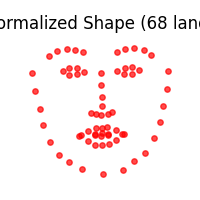

In [5]:
# Cell 5: Build mean normalized shape

# ==================== CONFIGURATION ====================
MIN_LANDMARKS = 5
OUT_MEAN_PATH = Path(DATA_PROCESSED) / "aligned" / "mean_norm_shape.npy"
OUT_MEAN_PATH.parent.mkdir(parents=True, exist_ok=True)

# ==================== HELPER FUNCTIONS ====================
def bbox_diag(pts):
    """Calculate diagonal length of bounding box for scaling."""
    xs, ys = pts[:, 0], pts[:, 1]
    return np.linalg.norm([xs.max() - xs.min(), ys.max() - ys.min()])

def normalize_shape(pts):
    """Center and scale landmarks to unit size."""
    centroid = pts.mean(axis=0)
    scale = bbox_diag(pts)
    if scale < 1e-6:
        scale = 1.0
    return (pts - centroid) / scale

def build_mean_normalized_shape(landmark_root=DATA_LANDMARKS):
    """Build mean shape from all landmark files."""
    all_norms = []
    counts = {}
    
    print(f"Scanning {landmark_root} for landmarks...")
    
    # Collect all landmark files
    for lm_path in landmark_root.rglob("*.npy"):
        # Skip shape files and non-photo files
        if "_shape" in lm_path.stem:
            continue
        if not lm_path.stem.lower().startswith('p'):
            continue
        
        try:
            pts = np.load(str(lm_path))
            
            # Validate
            if pts is None or pts.size == 0 or pts.shape[0] < MIN_LANDMARKS:
                continue
            if pts.ndim != 2 or pts.shape[1] != 2:
                continue
            
            all_norms.append(normalize_shape(pts))
            counts[pts.shape[0]] = counts.get(pts.shape[0], 0) + 1
            
        except Exception as e:
            continue
    
    if len(all_norms) == 0:
        raise RuntimeError("No valid landmarks found! Check your folder path or 'p' prefix filter.")
    
    # Use most common landmark count
    common_n = max(counts, key=counts.get)
    final_norms = [n for n in all_norms if n.shape[0] == common_n]
    
    print(f"Found {len(all_norms)} files. Using {len(final_norms)} shapes with {common_n} points.")
    
    # Compute mean shape
    mean_norm_shape = np.mean(np.stack(final_norms, axis=0), axis=0)
    np.save(OUT_MEAN_PATH, mean_norm_shape)
    print(f"✓ Saved mean normalized shape to: {OUT_MEAN_PATH}")
    
    return mean_norm_shape

# ==================== MAIN EXECUTION ====================
mean_norm = build_mean_normalized_shape()

# ==================== VISUALIZATION ====================
plt.figure(figsize=(2, 2))
plt.scatter(mean_norm[:, 0], -mean_norm[:, 1], s=15, c='red', alpha=0.7)
plt.axis('equal')
plt.axis('off')
plt.title(f"Mean Normalized Shape ({len(mean_norm)} landmarks)")
plt.tight_layout()
plt.show()

In [6]:
# Cell 6: Build canonical target_pts and transform helper


OUTPUT_SIZE = (256,256)
TARGET_FACE_SCALE = 0.55
MEAN_NORM_PATH = Path(DATA_PROCESSED) / "aligned" / "mean_norm_shape.npy"
TARGET_PTS_PATH = Path(DATA_PROCESSED) / "aligned" / "target_pts.npy"
TARGET_PTS_PATH.parent.mkdir(parents=True, exist_ok=True)

if MEAN_NORM_PATH.exists():
    mean_norm = np.load(str(MEAN_NORM_PATH))
else:
    try:
        mean_norm
    except NameError:
        raise RuntimeError("Mean normalized shape not found. Run Cell 5 first.")
    else:
        mean_norm = np.asarray(mean_norm)

w_out, h_out = OUTPUT_SIZE
center_out = np.array([w_out/2.0, h_out/2.0], dtype=np.float32)
target_scale = min(w_out, h_out) * TARGET_FACE_SCALE
target_pts = (mean_norm * target_scale + center_out).astype(np.float32)
np.save(str(TARGET_PTS_PATH), target_pts)
print("Saved target_pts:", TARGET_PTS_PATH)

def estimate_similarity_transform(src_pts, dst_pts, method='ransac'):
    src = np.asarray(src_pts, dtype=np.float32)
    dst = np.asarray(dst_pts, dtype=np.float32)
    if src.shape[0] < 3:
        raise ValueError("At least 3 points required")
    if method == 'ransac':
        M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.RANSAC,
                                                 ransacReprojThreshold=3.0, maxIters=2000)
        if M is None:
            M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
    else:
        M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
    if M is None:
        raise RuntimeError("estimateAffinePartial2D failed")
    return M# Cell 6: Build canonical target_pts and transform helper


OUTPUT_SIZE = (256,256)
TARGET_FACE_SCALE = 0.55
MEAN_NORM_PATH = Path(DATA_PROCESSED) / "aligned" / "mean_norm_shape.npy"
TARGET_PTS_PATH = Path(DATA_PROCESSED) / "aligned" / "target_pts.npy"
TARGET_PTS_PATH.parent.mkdir(parents=True, exist_ok=True)

if MEAN_NORM_PATH.exists():
    mean_norm = np.load(str(MEAN_NORM_PATH))
else:
    try:
        mean_norm
    except NameError:
        raise RuntimeError("Mean normalized shape not found. Run Cell 5 first.")
    else:
        mean_norm = np.asarray(mean_norm)

w_out, h_out = OUTPUT_SIZE
center_out = np.array([w_out/2.0, h_out/2.0], dtype=np.float32)
target_scale = min(w_out, h_out) * TARGET_FACE_SCALE
target_pts = (mean_norm * target_scale + center_out).astype(np.float32)
np.save(str(TARGET_PTS_PATH), target_pts)
print("Saved target_pts:", TARGET_PTS_PATH)

def estimate_similarity_transform(src_pts, dst_pts, method='ransac'):
    src = np.asarray(src_pts, dtype=np.float32)
    dst = np.asarray(dst_pts, dtype=np.float32)
    if src.shape[0] < 3:
        raise ValueError("At least 3 points required")
    if method == 'ransac':
        M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.RANSAC,
                                                 ransacReprojThreshold=3.0, maxIters=2000)
        if M is None:
            M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
    else:
        M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
    if M is None:
        raise RuntimeError("estimateAffinePartial2D failed")
    return M

Saved target_pts: D:\Projects 2025\Caricature Generation\data\processed\aligned\target_pts.npy
Saved target_pts: D:\Projects 2025\Caricature Generation\data\processed\aligned\target_pts.npy


In [7]:
# Cell 7: Robust batch alignment with hair-aware cropping

# ==================== CONFIGURATION ====================
OUTPUT_SIZE = (256, 256)
w_out, h_out = OUTPUT_SIZE
DEMO_LIMIT = None
VERBOSE = False  # Set to True to see processing details
BG_FILL = (30, 30, 30)

# Alignment settings
ALIGNMENT_METHOD = 'affine'     # 'similarity' or 'affine'
CROP_STRATEGY = 'adaptive'      # 'tight', 'adaptive', or 'loose'
FACE_SCALE = 0.45              # Face size relative to output (smaller = more room for hair)

# ==================== PATHS ====================
RAWROOT = Path(DATA_RAW)
LANDROOT = Path(DATA_LANDMARKS)
ALIGNED_ROOT = Path(DATA_ALIGNED)
ALIGNED_ROOT.mkdir(parents=True, exist_ok=True)

# ==================== HELPER FUNCTIONS ====================
def transform_landmarks(pts, M):
    """Apply 2x3 affine matrix to landmarks."""
    pts = np.asarray(pts, dtype=np.float32)
    ones = np.ones((pts.shape[0], 1), dtype=np.float32)
    homog = np.concatenate([pts, ones], axis=1)
    return homog @ M.T

def collect_photo_files(root_dir, limit=None):
    """Collect image files with filenames starting with 'p'."""
    files = []
    for img_path in root_dir.rglob('*'):
        if not img_path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}:
            continue
        if not img_path.stem.lower().startswith('p'):
            continue
        files.append(img_path)
        if limit and len(files) >= limit:
            break
    return files

def get_face_bbox_with_hair(pts, strategy='adaptive'):
    """
    Calculate face bounding box WITH HAIR included.
    Uses anatomical proportions to estimate head top.
    
    Args:
        pts: Landmarks (N, 2) - assumes 68-point format
        strategy: 'tight', 'adaptive', or 'loose'
    
    Returns:
        bbox: [x_min, y_min, x_max, y_max]
    """
    # Basic landmark bounds
    x_min, y_min = pts.min(axis=0)
    x_max, y_max = pts.max(axis=0)
    
    width = x_max - x_min
    height = y_max - y_min
    
    # Anatomical estimation for hair region
    # For 68-point landmarks: 17-26 are eyebrows, 8 is chin
    if len(pts) >= 27:
        eyebrow_top = pts[17:27, 1].min()  # Top of eyebrows
        jaw_bottom = pts[8, 1] if len(pts) > 8 else y_max  # Chin point
        face_height = jaw_bottom - eyebrow_top
        
        # Human proportions:
        # - Forehead (eyebrow to hairline): ~0.35x face height
        # - Hair volume: ~0.4-0.6x face height
        # - Total above eyebrows: ~0.75x face height
        head_top_estimate = eyebrow_top - (face_height * 0.75)
    else:
        # Fallback for non-standard landmark counts
        head_top_estimate = y_min - (height * 0.5)
    
    # Calculate asymmetric padding
    if strategy == 'tight':
        # Minimal padding - just enough for short hair
        pad_top = max(0, y_min - head_top_estimate) + height * 0.1
        pad_bottom = height * 0.1
        pad_x = width * 0.15
        
    elif strategy == 'adaptive':
        # Recommended - handles most hairstyles
        pad_top = max(0, y_min - head_top_estimate) + height * 0.25
        pad_bottom = height * 0.15
        pad_x = width * 0.25
        
    else:  # loose
        # Maximum padding - for very voluminous hair
        pad_top = max(0, y_min - head_top_estimate) + height * 0.45
        pad_bottom = height * 0.2
        pad_x = width * 0.35
    
    return [
        x_min - pad_x,
        y_min - pad_top,      # Lots of space for hair on top
        x_max + pad_x,
        y_max + pad_bottom    # Less space on bottom
    ]

def estimate_transform_robust(src_pts, dst_pts, method='affine'):
    """
    Estimate transform with multiple fallback strategies.
    NEVER returns None - always finds a transform.
    """
    src = np.asarray(src_pts, dtype=np.float32)
    dst = np.asarray(dst_pts, dtype=np.float32)
    
    # Strategy 1: Try with RANSAC
    try:
        if method == 'affine':
            M, _ = cv2.estimateAffine2D(src, dst, method=cv2.RANSAC, 
                                        ransacReprojThreshold=5.0, maxIters=2000)
        else:
            M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.RANSAC,
                                               ransacReprojThreshold=5.0, maxIters=2000)
        if M is not None:
            return M
    except:
        pass
    
    # Strategy 2: Try with LMEDS
    try:
        if method == 'affine':
            M, _ = cv2.estimateAffine2D(src, dst, method=cv2.LMEDS)
        else:
            M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
        if M is not None:
            return M
    except:
        pass
    
    # Strategy 3: Similarity transform with LMEDS
    try:
        M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
        if M is not None:
            return M
    except:
        pass
    
    # Strategy 4: Manual similarity based on centroids (ALWAYS works)
    src_center = src.mean(axis=0)
    dst_center = dst.mean(axis=0)
    
    # Calculate scale
    src_scale = np.sqrt(((src - src_center) ** 2).sum() / len(src))
    dst_scale = np.sqrt(((dst - dst_center) ** 2).sum() / len(dst))
    scale = dst_scale / (src_scale + 1e-8)
    
    # Simple scale + translation transform
    M = np.array([
        [scale, 0, dst_center[0] - scale * src_center[0]],
        [0, scale, dst_center[1] - scale * src_center[1]]
    ], dtype=np.float32)
    
    return M

def crop_and_align_face(img, pts, output_size, face_scale=0.45, crop_strategy='adaptive'):
    """
    Crop face region WITH HAIR and align to output size.
    ALWAYS succeeds by adjusting crop if needed.
    
    Returns:
        warped: Aligned image
        M: Transform matrix
        transformed_pts: Transformed landmarks
    """
    h_img, w_img = img.shape[:2]
    w_out, h_out = output_size
    
    # Get face bounding box with hair included
    bbox = get_face_bbox_with_hair(pts, strategy=crop_strategy)
    x_min, y_min, x_max, y_max = bbox
    
    # Ensure bbox is within image bounds
    x_min = max(0, x_min)
    y_min = max(0, y_min)
    x_max = min(w_img, x_max)
    y_max = min(h_img, y_max)
    
    # Crop dimensions
    crop_w = x_max - x_min
    crop_h = y_max - y_min
    
    # If crop is too small, expand it
    if crop_w < 50 or crop_h < 50:
        center_x = (x_min + x_max) / 2
        center_y = (y_min + y_max) / 2
        crop_w = max(crop_w, 100)
        crop_h = max(crop_h, 100)
        x_min = max(0, center_x - crop_w / 2)
        y_min = max(0, center_y - crop_h / 2)
        x_max = min(w_img, center_x + crop_w / 2)
        y_max = min(h_img, center_y + crop_h / 2)
    
    # Crop image and adjust landmarks
    x_min, y_min, x_max, y_max = int(x_min), int(y_min), int(x_max), int(y_max)
    cropped_img = img[y_min:y_max, x_min:x_max]
    cropped_pts = pts - np.array([x_min, y_min])
    
    # Calculate transform to output size
    # We want the FACE (not the full crop) to be at face_scale
    crop_center = np.array([cropped_img.shape[1] / 2, cropped_img.shape[0] / 2])
    target_center = np.array([w_out / 2, h_out / 2])
    
    # Scale based on face landmarks, not full crop
    face_bbox_in_crop = [
        cropped_pts[:, 0].min(),
        cropped_pts[:, 1].min(),
        cropped_pts[:, 0].max(),
        cropped_pts[:, 1].max()
    ]
    face_w = face_bbox_in_crop[2] - face_bbox_in_crop[0]
    face_h = face_bbox_in_crop[3] - face_bbox_in_crop[1]
    
    # Target scale keeps face at desired size (hair will naturally be included)
    target_scale = (min(w_out, h_out) * face_scale) / max(face_w, face_h)
    
    # Create target points
    pts_centered = cropped_pts - crop_center
    target_pts = pts_centered * target_scale + target_center
    
    # Estimate transform from cropped to output
    M = estimate_transform_robust(cropped_pts, target_pts, method=ALIGNMENT_METHOD)
    
    # Warp to output size
    warped = cv2.warpAffine(
        cropped_img, M, (w_out, h_out),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=BG_FILL
    )
    
    # Transform landmarks
    transformed_pts = transform_landmarks(cropped_pts, M)
    
    return warped, M, transformed_pts

# ==================== LOAD TARGET POINTS ====================
target_path = Path(DATA_PROCESSED) / "aligned" / "target_pts.npy"
if target_path.exists():
    dst_pts_full = np.load(str(target_path)).astype(np.float32)
    print(f"✓ Loaded target points: {dst_pts_full.shape[0]} landmarks")
else:
    print("⚠ Target points not found, will use adaptive alignment")
    dst_pts_full = None

# ==================== COLLECT FILES ====================
raw_images = collect_photo_files(RAWROOT, DEMO_LIMIT)
print(f"Found {len(raw_images)} images to align")
print(f"Crop strategy: {CROP_STRATEGY} (includes hair)")
print(f"Face scale: {FACE_SCALE} (smaller = more room for hair)")

# ==================== MAIN PROCESSING ====================
count_ok = 0
count_skipped = 0

for img_path in tqdm(raw_images, desc="Aligning images with hair"):
    if DEMO_LIMIT and count_ok >= DEMO_LIMIT:
        break
    
    # Determine paths
    rel_path = img_path.relative_to(RAWROOT)
    stem = rel_path.stem
    
    lm_src = LANDROOT / rel_path.with_suffix('.npy')
    out_img_path = ALIGNED_ROOT / f"{stem}_aligned.png"
    out_lm_path = ALIGNED_ROOT / f"{stem}_aligned.npy"
    out_M_path = ALIGNED_ROOT / f"{stem}_affine.npy"
    
    # Skip if no landmarks
    if not lm_src.exists():
        if VERBOSE:
            print(f"Skip (no landmarks): {rel_path}")
        continue
    
    # Skip if already processed
    if out_img_path.exists() and out_lm_path.exists() and out_M_path.exists():
        count_skipped += 1
        continue
    
    # Load image and landmarks
    try:
        src_pts = np.load(str(lm_src)).astype(np.float32)
        img = np.array(Image.open(img_path).convert('RGB'))
    except Exception as e:
        if VERBOSE:
            print(f"Load failed: {rel_path} - {e}")
        continue
    
    # Crop and align face WITH HAIR - ALWAYS succeeds
    try:
        warped, M, transformed_pts = crop_and_align_face(
            img, src_pts, (w_out, h_out), 
            face_scale=FACE_SCALE,
            crop_strategy=CROP_STRATEGY
        )
        
        # Save results
        out_img_path.parent.mkdir(parents=True, exist_ok=True)
        Image.fromarray(warped).save(str(out_img_path))
        np.save(str(out_lm_path), transformed_pts.astype(np.float32))
        np.save(str(out_M_path), M.astype(np.float32))
        
        count_ok += 1
        
    except Exception as e:
        if VERBOSE:
            print(f"Unexpected error: {rel_path} - {e}")
        continue

# ==================== SUMMARY ====================
print(f"\n{'='*60}")
print(f"Alignment Complete (Hair-Aware)")
print(f"{'='*60}")
print(f"✓ Aligned:  {count_ok}")
print(f"○ Skipped:  {count_skipped}")
print(f"Strategy:   {CROP_STRATEGY} crop + {ALIGNMENT_METHOD.upper()}")
print(f"Face scale: {FACE_SCALE} (leaves room for hair)")
print(f"Output dir: {ALIGNED_ROOT}")
print(f"{'='*60}")

✓ Loaded target points: 68 landmarks
Found 5974 images to align
Crop strategy: adaptive (includes hair)
Face scale: 0.45 (smaller = more room for hair)


Aligning images with hair: 100%|████████████████████████████████████████████████| 5974/5974 [00:00<00:00, 23065.76it/s]


Alignment Complete (Hair-Aware)
✓ Aligned:  0
○ Skipped:  100
Strategy:   adaptive crop + AFFINE
Face scale: 0.45 (leaves room for hair)
Output dir: D:\Projects 2025\Caricature Generation\data\processed\aligned


In [8]:
# Cell 8: Full-image TPS warp with Procrustes + RBF-based exaggeration
import numpy as np
import cv2
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import scipy.linalg

# ==================== PARAMETERS ====================
REG = 1e-2
GRID_STEP = 2
FALLOFF_RADIUS_FACTOR = 1.8
FALLOFF_SHARPNESS = 2.0
DEMO_N = None       # None -> all aligned images; or set to small int for demo
OUT_SUBDIR = "tps_normalized"
DEBUG = False

# NEW: RBF-based exaggeration controls
RBF_SIGMA = 40.0           # Controls spatial falloff of local exaggeration
MIN_MOVEMENT_THRESHOLD = 2.0  # Minimum pixel movement to consider for exaggeration
EXAGGERATION_SCALE = 1.5    # Multiplier for exaggeration (1.0 = proportional, >1.0 = more dramatic)

# Features to exaggerate locally (indices for 68-point landmarks)
LOCAL_FEATURE_GROUPS = {
    'left_eyebrow': list(range(17, 22)),
    'right_eyebrow': list(range(22, 27)),
    'nose': list(range(27, 36)),
    'left_eye': list(range(36, 42)),
    'right_eye': list(range(42, 48)),
    'mouth': list(range(48, 68)),
}

ALIGNED_ROOT = Path(DATA_ALIGNED)
OUT_ROOT = Path(DATA_PROCESSED) / OUT_SUBDIR 
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# ==================== TPS FUNCTIONS ====================
def _tps_kernel(r):
    out = np.zeros_like(r, dtype=np.float64)
    nz = r > 0
    out[nz] = (r[nz]**2) * np.log(r[nz])
    return out

def solve_tps(ctrl_pts, target_vals, reg=1e-3):
    N = ctrl_pts.shape[0]
    diff = ctrl_pts[:, None, :] - ctrl_pts[None, :, :]
    r = np.sqrt((diff**2).sum(axis=2))
    K = _tps_kernel(r)
    P = np.concatenate([np.ones((N,1)), ctrl_pts], axis=1)
    A = np.zeros((N+3, N+3), dtype=np.float64)
    A[:N, :N] = K + reg * np.eye(N)
    A[:N, N:] = P
    A[N:, :N] = P.T
    rhs = np.zeros((N+3,), dtype=np.float64)
    rhs[:N] = target_vals.astype(np.float64)
    coeffs = scipy.linalg.solve(A, rhs, assume_a='sym')
    w = coeffs[:N]; a = coeffs[N:]
    return w, a

def tps_eval_grid(ctrl_pts, w, a, xs, ys):
    XX, YY = np.meshgrid(xs, ys)
    pts = np.stack([XX.ravel(), YY.ravel()], axis=1)
    diff = pts[:, None, :] - ctrl_pts[None, :, :]
    r = np.sqrt((diff**2).sum(axis=2))
    U = _tps_kernel(r)
    fflat = U.dot(w) + a[0] + a[1]*pts[:,0] + a[2]*pts[:,1]
    return fflat.reshape(len(ys), len(xs))

# ==================== PROCRUSTES + RBF EXAGGERATION ====================
def procrustes_alignment(src_pts, dst_pts):
    """
    Compute Procrustes alignment: rotation, translation, and GLOBAL SCALE.
    Returns the global scale factor.
    """
    src = src_pts - src_pts.mean(axis=0)
    dst = dst_pts - dst_pts.mean(axis=0)
    
    src_scale = np.sqrt((src**2).sum())
    dst_scale = np.sqrt((dst**2).sum())
    
    global_scale = dst_scale / (src_scale + 1e-8)
    return global_scale

def compute_landmark_movements(src_pts, dst_pts):
    """
    Compute how much each landmark moved.
    Returns movement distances for each landmark.
    """
    movements = np.linalg.norm(dst_pts - src_pts, axis=1)
    return movements

def gaussian_rbf(distance, sigma):
    """Gaussian RBF kernel."""
    return np.exp(-(distance**2) / (2 * sigma**2))

def compute_rbf_exaggeration_field(pts, movements, sigma=40.0, threshold=2.0):
    """
    Compute spatially-varying exaggeration factors using Gaussian RBF.
    
    Args:
        pts: Landmark positions (N, 2)
        movements: Movement distance for each landmark (N,)
        sigma: Spatial falloff parameter
        threshold: Minimum movement to consider
    
    Returns:
        Function that takes (x, y) and returns local exaggeration factor
    """
    # Filter landmarks that moved significantly
    significant = movements > threshold
    if not np.any(significant):
        # No significant movement, return uniform field
        return lambda x, y: np.ones_like(x)
    
    active_pts = pts[significant]
    active_movements = movements[significant]
    
    # Normalize movements to create weights
    max_movement = active_movements.max()
    weights = active_movements / (max_movement + 1e-8)
    
    def exaggeration_at(x, y):
        """Evaluate exaggeration field at grid positions."""
        # Handle both scalar and array inputs
        x = np.atleast_1d(x)
        y = np.atleast_1d(y)
        
        # Reshape for broadcasting
        query_pts = np.stack([x.ravel(), y.ravel()], axis=1)  # (M, 2)
        
        # Compute distances to all active landmarks
        dists = np.linalg.norm(
            query_pts[:, None, :] - active_pts[None, :, :], 
            axis=2
        )  # (M, N_active)
        
        # Apply Gaussian RBF
        rbf_values = gaussian_rbf(dists, sigma)  # (M, N_active)
        
        # Weighted sum: exaggeration = 1.0 + sum(weight * rbf)
        exag = 1.0 + (rbf_values * weights[None, :]).sum(axis=1)
        
        return exag.reshape(x.shape)
    
    return exaggeration_at

def apply_adaptive_exaggeration(src_pts, dst_pts, exag_scale=1.5, 
                                 rbf_sigma=40.0, threshold=2.0):
    """
    Apply Procrustes global scale + RBF local exaggeration.
    
    Args:
        src_pts: Original landmark positions
        dst_pts: Target landmark positions (e.g., mean shape)
        exag_scale: Multiplier for exaggeration effect
        rbf_sigma: Spatial falloff for RBF
        threshold: Minimum movement threshold
    
    Returns:
        Exaggerated landmark positions
    """
    # Step 1: Procrustes global scale
    global_scale = procrustes_alignment(src_pts, dst_pts)
    
    # Step 2: Compute movements
    movements = compute_landmark_movements(src_pts, dst_pts)
    
    # Step 3: Create RBF exaggeration field
    exag_field = compute_rbf_exaggeration_field(src_pts, movements, rbf_sigma, threshold)
    
    # Step 4: Apply to each landmark
    src_center = src_pts.mean(axis=0)
    pts_exag = src_pts.copy()
    
    for i in range(len(src_pts)):
        # Get local exaggeration factor
        local_factor = exag_field(src_pts[i, 0], src_pts[i, 1])
        
        # Combine global and local: exag = global * (1 + local_boost)
        combined_factor = global_scale * (1.0 + (local_factor - 1.0) * exag_scale)
        
        # Apply from center
        pts_exag[i] = src_center + combined_factor * (src_pts[i] - src_center)
    
    return pts_exag

def compute_tps_warp(img, src_pts, dst_pts, grid_step=2):
    """
    Compute TPS warp maps from src_pts to dst_pts.
    Returns the displacement maps (map_x, map_y).
    """
    h, w = img.shape[:2]
    
    # Solve inverse TPS
    w_x, a_x = solve_tps(dst_pts, src_pts[:,0], reg=REG)
    w_y, a_y = solve_tps(dst_pts, src_pts[:,1], reg=REG)
    
    # Evaluate on grid
    if grid_step <= 1:
        xs = np.arange(0, w)
        ys = np.arange(0, h)
        map_x = tps_eval_grid(dst_pts, w_x, a_x, xs, ys)
        map_y = tps_eval_grid(dst_pts, w_y, a_y, xs, ys)
    else:
        xs_c = np.arange(0, w, grid_step)
        ys_c = np.arange(0, h, grid_step)
        map_xc = tps_eval_grid(dst_pts, w_x, a_x, xs_c, ys_c)
        map_yc = tps_eval_grid(dst_pts, w_y, a_y, xs_c, ys_c)
        map_x = cv2.resize(map_xc.astype(np.float32), (w, h), interpolation=cv2.INTER_CUBIC)
        map_y = cv2.resize(map_yc.astype(np.float32), (w, h), interpolation=cv2.INTER_CUBIC)
    
    return map_x, map_y

# ==================== MAIN PROCESSING ====================
aligned_imgs = sorted(list(ALIGNED_ROOT.rglob("*_aligned.png")))
aligned_imgs = [p for p in aligned_imgs if p.stem.lower().startswith('p')]

if len(aligned_imgs) == 0:
    raise RuntimeError("No aligned images found. Run alignment first.")

to_process = aligned_imgs if DEMO_N is None else aligned_imgs[:DEMO_N]

# Load mean shape for Procrustes comparison
mean_shape_path = Path(DATA_PROCESSED) / "aligned" / "target_pts.npy"
if mean_shape_path.exists():
    mean_shape_template = np.load(str(mean_shape_path)).astype(np.float64)
    print(f"✓ Loaded mean shape template: {mean_shape_template.shape}")
else:
    mean_shape_template = None
    print("⚠ Mean shape not found, will use normalized self-comparison")

print(f"Processing with RBF_SIGMA={RBF_SIGMA}, EXAGGERATION_SCALE={EXAGGERATION_SCALE}")

for p in to_process:
    lm_p = Path(str(p).replace("_aligned.png", "_aligned.npy"))
    if not lm_p.exists():
        print("Skip (no lm):", p)
        continue
    
    out_path = OUT_ROOT / (p.stem.replace("_aligned", "") + "_tps.png")

    try:
        img = np.array(Image.open(p).convert("RGB"))
        h, w = img.shape[:2]
        pts = np.load(str(lm_p)).astype(np.float64)

        # Use mean shape if available, otherwise use self
        if mean_shape_template is not None and len(mean_shape_template) == len(pts):
            mean_shape = mean_shape_template
        else:
            mean_shape = pts.copy()

        # Apply adaptive exaggeration based on Procrustes + RBF
        pts_final = apply_adaptive_exaggeration(
            pts, mean_shape, 
            exag_scale=EXAGGERATION_SCALE,
            rbf_sigma=RBF_SIGMA,
            threshold=MIN_MOVEMENT_THRESHOLD
        )

        # Compute TPS warp from original to final
        map_x, map_y = compute_tps_warp(img, pts, pts_final, GRID_STEP)

        # Identity grid
        id_x = np.tile(np.arange(w, dtype=np.float32)[None, :], (h, 1))
        id_y = np.tile(np.arange(h, dtype=np.float32)[:, None], (1, w))

        # Gaussian falloff
        centroid = pts.mean(axis=0)
        bbox_diag = np.linalg.norm([pts[:,0].max()-pts[:,0].min(), pts[:,1].max()-pts[:,1].min()])
        radius = bbox_diag * FALLOFF_RADIUS_FACTOR if bbox_diag > 1e-6 else max(h,w)*0.25
        xx, yy = np.meshgrid(np.arange(w), np.arange(h))
        dist = np.sqrt((xx - centroid[0])**2 + (yy - centroid[1])**2)
        weight = np.exp(- (dist / (radius + 1e-8))**2 * FALLOFF_SHARPNESS).astype(np.float32)

        # Blend TPS warp with identity
        final_map_x = (1.0 - weight) * id_x + weight * map_x.astype(np.float32)
        final_map_y = (1.0 - weight) * id_y + weight * map_y.astype(np.float32)

        final_map_x = np.clip(final_map_x, 0.0, float(w-1)).astype(np.float32)
        final_map_y = np.clip(final_map_y, 0.0, float(h-1)).astype(np.float32)

        # Apply warp
        src_u8 = np.clip(img, 0, 255).astype(np.uint8)
        warped = cv2.remap(src_u8, final_map_x, final_map_y, 
                          interpolation=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_CONSTANT, 
                          borderValue=(0,0,0))

        out_path.parent.mkdir(parents=True, exist_ok=True)
        Image.fromarray(warped).save(str(out_path))

        if DEBUG:
            fig, ax = plt.subplots(1, 3, figsize=(15, 5))
            
            ax[0].imshow(img)
            ax[0].set_title("Original")
            ax[0].scatter(pts[:,0], pts[:,1], c='red', s=10, alpha=0.5)
            ax[0].axis('off')
            
            ax[1].imshow(warped)
            ax[1].set_title(f"RBF Exaggerated (scale={EXAGGERATION_SCALE})")
            ax[1].scatter(pts_final[:,0], pts_final[:,1], c='green', s=10, alpha=0.5)
            ax[1].axis('off')
            
            ax[2].imshow(weight, cmap='inferno')
            ax[2].set_title("Falloff Weight")
            ax[2].axis('off')
            
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print("Failed:", p, e)
        continue

print(f"\n✓ TPS outputs saved to: {OUT_ROOT}")

C:\Users\nahia\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.20133e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


✓ Loaded mean shape template: (68, 2)
Processing with RBF_SIGMA=40.0, EXAGGERATION_SCALE=1.5


C:\Users\nahia\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.86467e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\nahia\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.75749e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\nahia\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.6072e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\nahia\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.48835e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\nahia\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\_lib\_


✓ TPS outputs saved to: D:\Projects 2025\Caricature Generation\data\processed\tps_normalized


In [9]:
# Alternative version using ipywidgets - FIXED display issues

import numpy as np
import cv2
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import scipy.linalg
import ipywidgets as widgets
from IPython.display import display

# ==================== CONFIGURATION ====================
DEMO_IMAGE_INDEX = 0

AVAILABLE_FEATURES = {
    'Left Eyebrow': list(range(17, 22)),
    'Right Eyebrow': list(range(22, 27)),
    'Nose': list(range(27, 36)),
    'Left Eye': list(range(36, 42)),
    'Right Eye': list(range(42, 48)),
    'Mouth': list(range(48, 68)),
    'Jaw': list(range(0, 17)),
}

DEFAULT_SETTINGS = {
    'RBF_SIGMA': 40.0,
    'EXAGGERATION_SCALE': 1.5,
    'MIN_MOVEMENT_THRESHOLD': 2.0,
    'FALLOFF_RADIUS_FACTOR': 1.8,
    'FALLOFF_SHARPNESS': 2.0,
    'REG': 1e-2,
    'GRID_STEP': 2,
}

# ==================== LOAD DATA ====================
ALIGNED_ROOT = Path(DATA_ALIGNED)
aligned_imgs = sorted(list(ALIGNED_ROOT.rglob("*_aligned.png")))
aligned_imgs = [p for p in aligned_imgs if p.stem.lower().startswith('p')]

if len(aligned_imgs) == 0:
    raise RuntimeError("No aligned images found.")

demo_img_path = aligned_imgs[DEMO_IMAGE_INDEX]
demo_lm_path = Path(str(demo_img_path).replace("_aligned.png", "_aligned.npy"))

img_original = np.array(Image.open(demo_img_path).convert("RGB"))
pts_original = np.load(str(demo_lm_path)).astype(np.float64)

mean_shape_path = Path(DATA_PROCESSED) / "aligned" / "target_pts.npy"
mean_shape = np.load(str(mean_shape_path)).astype(np.float64) if mean_shape_path.exists() else pts_original.copy()

print(f"✓ Loaded: {demo_img_path.name}")
print(f"✓ Image shape: {img_original.shape}")
print(f"✓ Landmarks shape: {pts_original.shape}")

# ==================== FUNCTIONS ====================
def _tps_kernel(r):
    out = np.zeros_like(r, dtype=np.float64)
    nz = r > 0
    out[nz] = (r[nz]**2) * np.log(r[nz])
    return out

def solve_tps(ctrl_pts, target_vals, reg=1e-2):
    N = ctrl_pts.shape[0]
    diff = ctrl_pts[:, None, :] - ctrl_pts[None, :, :]
    r = np.sqrt((diff**2).sum(axis=2))
    K = _tps_kernel(r)
    P = np.concatenate([np.ones((N,1)), ctrl_pts], axis=1)
    A = np.zeros((N+3, N+3), dtype=np.float64)
    A[:N, :N] = K + reg * np.eye(N)
    A[:N, N:] = P
    A[N:, :N] = P.T
    rhs = np.zeros((N+3,), dtype=np.float64)
    rhs[:N] = target_vals.astype(np.float64)
    
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        coeffs = scipy.linalg.solve(A, rhs, assume_a='sym')
    
    return coeffs[:N], coeffs[N:]

def tps_eval_grid(ctrl_pts, w, a, xs, ys):
    XX, YY = np.meshgrid(xs, ys)
    pts = np.stack([XX.ravel(), YY.ravel()], axis=1)
    diff = pts[:, None, :] - ctrl_pts[None, :, :]
    r = np.sqrt((diff**2).sum(axis=2))
    U = _tps_kernel(r)
    fflat = U.dot(w) + a[0] + a[1]*pts[:,0] + a[2]*pts[:,1]
    return fflat.reshape(len(ys), len(xs))

def gaussian_rbf(distance, sigma):
    return np.exp(-(distance**2) / (2 * sigma**2))

def apply_selective_exaggeration(src_pts, mean_pts, active_indices, settings):
    movements = np.linalg.norm(mean_pts - src_pts, axis=1)
    exag_mask = np.zeros(len(src_pts), dtype=bool)
    exag_mask[active_indices] = True
    filtered_movements = movements.copy()
    filtered_movements[~exag_mask] = 0.0
    
    threshold = settings['MIN_MOVEMENT_THRESHOLD']
    significant = (filtered_movements > threshold) & exag_mask
    
    if not np.any(significant):
        return src_pts.copy()
    
    active_pts = src_pts[significant]
    active_movements = filtered_movements[significant]
    max_movement = active_movements.max()
    weights = active_movements / (max_movement + 1e-8)
    
    src_center = src_pts.mean(axis=0)
    pts_exag = src_pts.copy()
    sigma = settings['RBF_SIGMA']
    exag_scale = settings['EXAGGERATION_SCALE']
    
    for i in range(len(src_pts)):
        if not exag_mask[i]:
            continue
        dists = np.linalg.norm(src_pts[i] - active_pts, axis=1)
        rbf_values = gaussian_rbf(dists, sigma)
        local_factor = 1.0 + (rbf_values * weights).sum()
        combined_factor = 1.0 + (local_factor - 1.0) * exag_scale
        pts_exag[i] = src_center + combined_factor * (src_pts[i] - src_center)
    
    return pts_exag

def apply_tps_warp(img, src_pts, dst_pts, settings):
    h, w = img.shape[:2]
    
    # Ensure points are valid
    if len(src_pts) != len(dst_pts):
        raise ValueError(f"Point count mismatch: {len(src_pts)} vs {len(dst_pts)}")
    
    # Solve TPS
    w_x, a_x = solve_tps(dst_pts, src_pts[:,0], reg=settings['REG'])
    w_y, a_y = solve_tps(dst_pts, src_pts[:,1], reg=settings['REG'])
    
    # Evaluate on coarse grid
    grid_step = settings['GRID_STEP']
    xs_c = np.arange(0, w, grid_step, dtype=np.float32)
    ys_c = np.arange(0, h, grid_step, dtype=np.float32)
    
    map_xc = tps_eval_grid(dst_pts, w_x, a_x, xs_c, ys_c)
    map_yc = tps_eval_grid(dst_pts, w_y, a_y, xs_c, ys_c)
    
    # Resize to full resolution
    map_x = cv2.resize(map_xc.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
    map_y = cv2.resize(map_yc.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
    
    # Identity grid
    id_x = np.tile(np.arange(w, dtype=np.float32)[None, :], (h, 1))
    id_y = np.tile(np.arange(h, dtype=np.float32)[:, None], (1, w))
    
    # Compute falloff
    centroid = src_pts.mean(axis=0)
    bbox_diag = np.linalg.norm([src_pts[:,0].max()-src_pts[:,0].min(), 
                                src_pts[:,1].max()-src_pts[:,1].min()])
    radius = bbox_diag * settings['FALLOFF_RADIUS_FACTOR'] if bbox_diag > 1e-6 else max(h,w)*0.25
    
    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    dist = np.sqrt((xx - centroid[0])**2 + (yy - centroid[1])**2)
    weight = np.exp(- (dist / (radius + 1e-8))**2 * settings['FALLOFF_SHARPNESS']).astype(np.float32)
    
    # Blend maps
    final_map_x = (1.0 - weight) * id_x + weight * map_x
    final_map_y = (1.0 - weight) * id_y + weight * map_y
    
    # Clip to valid range
    final_map_x = np.clip(final_map_x, 0.0, float(w-1))
    final_map_y = np.clip(final_map_y, 0.0, float(h-1))
    
    # Apply warp
    src_u8 = np.clip(img, 0, 255).astype(np.uint8)
    warped = cv2.remap(src_u8, final_map_x, final_map_y, 
                      interpolation=cv2.INTER_LINEAR,
                      borderMode=cv2.BORDER_REPLICATE)
    
    # Verify output
    if warped is None or warped.size == 0:
        print("⚠️ Warning: Warp failed, returning original")
        return img, weight
    
    return warped, weight

# ==================== INTERACTIVE UI ====================
class InteractiveExaggerator:
    def __init__(self):
        self.settings = DEFAULT_SETTINGS.copy()
        self.selected_features = {name: True for name in AVAILABLE_FEATURES.keys()}
        
        # Create output
        self.output = widgets.Output()
        
        # Create controls
        self.slider_exag = widgets.FloatSlider(
            value=1.5, min=0.5, max=3.0, step=0.1,
            description='Exaggeration:', 
            style={'description_width': '120px'},
            layout=widgets.Layout(width='400px')
        )
        self.slider_sigma = widgets.FloatSlider(
            value=40.0, min=10.0, max=100.0, step=5.0,
            description='RBF Sigma:', 
            style={'description_width': '120px'},
            layout=widgets.Layout(width='400px')
        )
        self.slider_threshold = widgets.FloatSlider(
            value=2.0, min=0.5, max=10.0, step=0.5,
            description='Threshold:', 
            style={'description_width': '120px'},
            layout=widgets.Layout(width='400px')
        )
        
        # Checkboxes for features
        self.checkboxes = {
            name: widgets.Checkbox(value=True, description=name, indent=False)
            for name in AVAILABLE_FEATURES.keys()
        }
        
        # Connect events
        self.slider_exag.observe(self.on_change, names='value')
        self.slider_sigma.observe(self.on_change, names='value')
        self.slider_threshold.observe(self.on_change, names='value')
        for cb in self.checkboxes.values():
            cb.observe(self.on_change, names='value')
        
        # Create layout
        sliders = widgets.VBox([
            widgets.HTML("<h3>🎚️ Exaggeration Controls</h3>"),
            self.slider_exag,
            self.slider_sigma,
            self.slider_threshold
        ])
        
        checkboxes_box = widgets.VBox([
            widgets.HTML("<h3>✅ Select Features</h3>")
        ] + list(self.checkboxes.values()))
        
        controls = widgets.HBox([sliders, checkboxes_box])
        
        self.ui = widgets.VBox([controls, self.output])
        
        # Initial render
        self.update()
    
    def get_active_indices(self):
        active = []
        for name, checkbox in self.checkboxes.items():
            if checkbox.value:
                active.extend(AVAILABLE_FEATURES[name])
        return sorted(set(active))
    
    def on_change(self, change):
        self.update()
    
    def update(self):
        self.settings['EXAGGERATION_SCALE'] = self.slider_exag.value
        self.settings['RBF_SIGMA'] = self.slider_sigma.value
        self.settings['MIN_MOVEMENT_THRESHOLD'] = self.slider_threshold.value
        
        active_indices = self.get_active_indices()
        
        with self.output:
            self.output.clear_output(wait=True)
            
            if len(active_indices) == 0:
                print("⚠️ No features selected! Check some boxes above.")
                return
            
            try:
                # Process
                pts_exag = apply_selective_exaggeration(pts_original, mean_shape, 
                                                       active_indices, self.settings)
                warped, weight = apply_tps_warp(img_original, pts_original, 
                                               pts_exag, self.settings)
                
                # Verify warped image
                if warped.shape != img_original.shape:
                    print(f"⚠️ Shape mismatch! Original: {img_original.shape}, Warped: {warped.shape}")
                    warped = img_original.copy()
                
                # Create figure with fixed size
                fig, axes = plt.subplots(1, 3, figsize=(16, 5))
                
                # Original with landmarks
                axes[0].imshow(img_original)
                axes[0].scatter(pts_original[:,0], pts_original[:,1], 
                              c='red', s=10, alpha=0.5, label='All')
                for i in active_indices:
                    axes[0].scatter(pts_original[i,0], pts_original[i,1], 
                                  c='lime', s=30, marker='o', 
                                  edgecolors='black', linewidths=1.5, zorder=10)
                axes[0].set_title(f'Original (Selected = Green)\n{len(active_indices)} features active', 
                                fontsize=11, fontweight='bold')
                axes[0].axis('off')
                axes[0].set_xlim(0, img_original.shape[1])
                axes[0].set_ylim(img_original.shape[0], 0)
                
                # Warped with landmarks
                axes[1].imshow(warped)
                axes[1].scatter(pts_exag[:,0], pts_exag[:,1], 
                              c='cyan', s=10, alpha=0.7)
                axes[1].set_title(f'Exaggerated Result\nScale: {self.slider_exag.value:.1f}x', 
                                fontsize=11, fontweight='bold')
                axes[1].axis('off')
                axes[1].set_xlim(0, warped.shape[1])
                axes[1].set_ylim(warped.shape[0], 0)
                
                # Weight map
                axes[2].imshow(weight, cmap='inferno')
                axes[2].set_title('Warp Intensity\n(Falloff Map)', 
                                fontsize=11, fontweight='bold')
                axes[2].axis('off')
                
                plt.tight_layout()
                plt.show()
                
                # Debug info
                print(f"✓ Processed: {len(active_indices)} features | "
                      f"Exag: {self.slider_exag.value:.1f}x | "
                      f"Sigma: {self.slider_sigma.value:.0f}")
                
            except Exception as e:
                print(f"❌ Error during processing: {e}")
                import traceback
                traceback.print_exc()
    
    def display(self):
        display(self.ui)

# Create and display
app = InteractiveExaggerator()
app.display()

print("\n✅ Interactive controls loaded! Adjust sliders and checkboxes above.")

✓ Loaded: P00001_aligned.png
✓ Image shape: (256, 256, 3)
✓ Landmarks shape: (68, 2)



✅ Interactive controls loaded! Adjust sliders and checkboxes above.
